In [221]:
import pandas as pd
import matplotlib.pyplot as plt

In [222]:
csv_path = '~/smt-napsat-conflicts-wo-avg.csv'
df = pd.read_csv(csv_path)
#df.columns = ['experiment', "-rscb", "-ncb", "-gb", "-rscb-c", "-ncb-c", "-gb-c", "-rscb-avg", "-ncb-avg", "-gb-avg"]
df.columns = ['experiment', "-rscb", "-ncb", "-gb", "-rscb-c", "-ncb-c", "-gb-c"]

In [223]:
print(len(df))

# Calculate comparisons between "-ncb" and "-gb"
ncb_gt_gb = (df["-ncb"] > df["-gb"]).sum()
ncb_lt_gb = (df["-ncb"] < df["-gb"]).sum()
ncb_eq_gb = (df["-ncb"] == df["-gb"]).sum()
print(f"-ncb > -gb: {ncb_gt_gb}")
print(f"-ncb < -gb: {ncb_lt_gb}")
print(f"-ncb == -gb: {ncb_eq_gb}")

# Calculate the average difference between "-ncb" and "-gb"
avg_diff = (df["-ncb"] - df["-gb"]).mean()
print(f"Average difference (-ncb - -gb): {avg_diff}")

2772374
-ncb > -gb: 1303221
-ncb < -gb: 922481
-ncb == -gb: 546672
Average difference (-ncb - -gb): 6.640108802059173


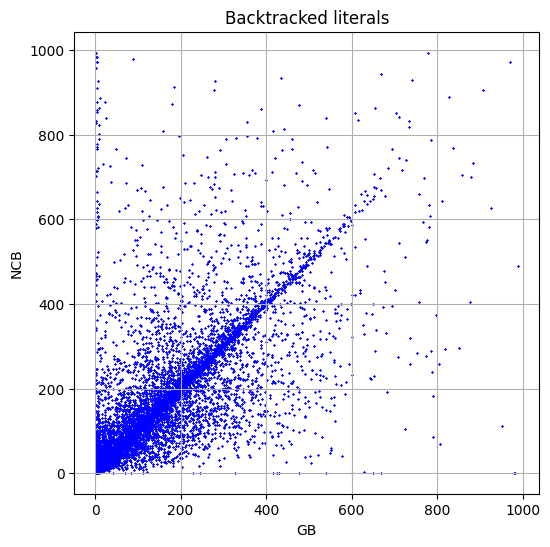

In [224]:
N = 10000
plot_sample = df.sample(n=N, random_state=4) if len(df) > N else df
plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["-gb"], plot_sample["-ncb"], alpha=1, s=0.5, c='blue', marker='x')
plt.xlabel("GB")
plt.ylabel("NCB")
plt.title("Backtracked literals")
plt.grid(True)
plt.savefig("/home/tom/smt-napsat-eval.pdf")
plt.savefig("/home/tom/smt-napsat-eval.png")
plt.show()

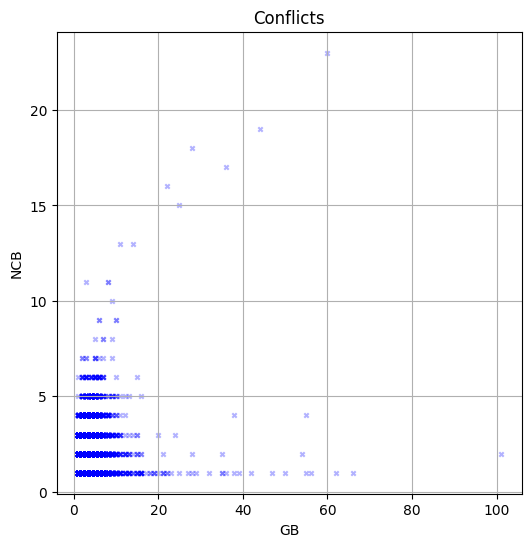

In [225]:
N = 50000
plot_sample = df.sample(n=N, random_state=4) if len(df) > N else df
plt.figure(figsize=(6, 6))
plt.scatter(plot_sample["-gb-c"], plot_sample["-ncb-c"], alpha=0.3, s=10, c='blue', marker='x')
plt.xlabel("GB")
plt.ylabel("NCB")
plt.title("Conflicts")
plt.grid(True)
plt.show()

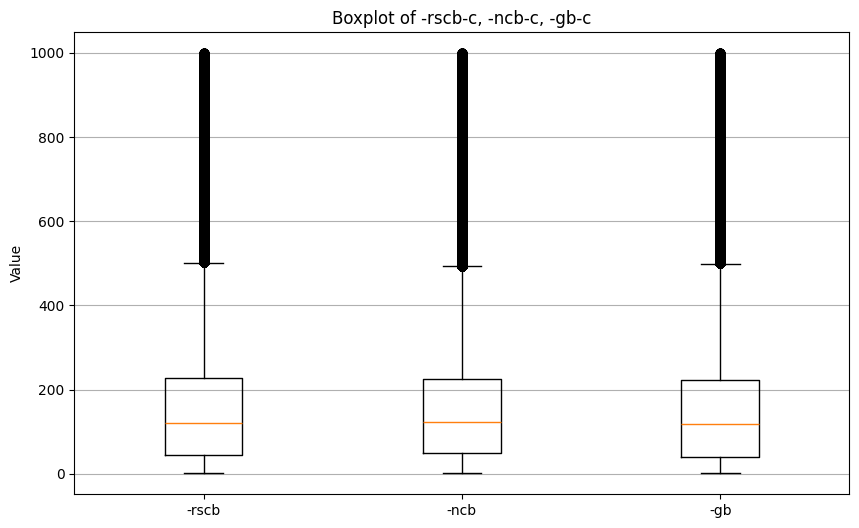

In [226]:

# Boxplot of the last three columns: -rscb-c, -ncb-c, -gb-c
plt.figure(figsize=(10, 6))
plt.boxplot([df["-rscb"], df["-ncb"], df["-gb"]], tick_labels=["-rscb", "-ncb", "-gb"])
plt.ylabel("Value")
plt.title("Boxplot of -rscb-c, -ncb-c, -gb-c")
plt.grid(True, axis='y')
plt.show()

In [227]:

# Print the average of the last three columns
avg_rscb_c = df["-rscb-c"].mean()
avg_ncb_c = df["-ncb-c"].mean()
avg_gb_c = df["-gb-c"].mean()
print(f"Average -rscb-c: {avg_rscb_c}")
print(f"Average -ncb-c: {avg_ncb_c}")
print(f"Average -gb-c: {avg_gb_c}")

Average -rscb-c: 1.5428744462327233
Average -ncb-c: 1.4555647975345318
Average -gb-c: 2.0146906586196525


## Clustering

In [228]:
print("## Count")
print ("Total:", len(df))
for i, ddf in enumerate(dfs):
    print(names[i], len(ddf))

## Count
Total: 2772374
Tiny 70772
Small 364219
Medium 276499
Big 1484957
Huge 575927


In [229]:
print("## Ratios")
for i, ddf in enumerate(dfs):
    ncb_gt_gb = (ddf["-ncb"] > ddf["-gb"]).sum()
    ncb_lt_gb = (ddf["-ncb"] < ddf["-gb"]).sum()
    ncb_eq_gb = (ddf["-ncb"] == ddf["-gb"]).sum()
    print(f"{names[i]}: -ncb > -gb: {round(ncb_gt_gb*100/len(ddf),2)}%, -ncb < -gb: {round(ncb_lt_gb*100/len(ddf),2)}%, -ncb == -gb: {round(ncb_eq_gb*100/len(ddf),2)}%")

## Ratios
Tiny: -ncb > -gb: 42.04%, -ncb < -gb: 13.82%, -ncb == -gb: 44.14%
Small: -ncb > -gb: 48.01%, -ncb < -gb: 17.21%, -ncb == -gb: 34.78%
Medium: -ncb > -gb: 49.56%, -ncb < -gb: 25.19%, -ncb == -gb: 25.25%
Big: -ncb > -gb: 44.48%, -ncb < -gb: 37.21%, -ncb == -gb: 18.32%
Huge: -ncb > -gb: 52.28%, -ncb < -gb: 39.56%, -ncb == -gb: 8.15%


In [230]:
df_tiny = df[df["-gb"] + df["-ncb"] <= 10]
df_small = df[(df["-gb"] + df["-ncb"] > 10) & (df["-gb"] + df["-ncb"] <= 50)]
df_med = df[(df["-gb"] + df["-ncb"] > 50) & (df["-gb"] + df["-ncb"] <= 100)]
df_big = df[(df["-gb"] + df["-ncb"] > 100) & (df["-gb"] + df["-ncb"] <= 500)]
df_huge = df[df["-gb"] + df["-ncb"] > 500]

dfs = [df_tiny, df_small, df_med, df_big, df_huge]
names = ["Tiny", "Small", "Medium", "Big", "Huge"]

In [231]:
print("## Average Differences (-ncb - -gb)")
for i, ddf in enumerate(dfs):
    avg_diff = round((ddf["-ncb"] - ddf["-gb"]).mean(), 2)
    std_diff = round((ddf["-ncb"] - ddf["-gb"]).std(), 2)
    print(f"{names[i]}: {avg_diff} \\x {std_diff}")


## Average Differences (-ncb - -gb)
Tiny: 0.83 \x 2.19
Small: 3.5 \x 8.97
Medium: 8.03 \x 23.15
Big: 3.09 \x 76.1
Huge: 17.83 \x 199.8


In [232]:
print("## Average unassignments")
for i, ddf in enumerate(dfs):
    avg_ncb = round(ddf["-ncb"].mean(), 2)
    std_ncb = round(ddf["-ncb"].std(), 2)
    avg_gb = round(ddf["-gb"].mean(), 2)
    std_gb = round(ddf["-gb"].std(), 2)
    print(f"{names[i]}: {avg_ncb} \\x {std_ncb}, -gb: mean={avg_gb} \\x {std_gb}")

## Average unassignments
Tiny: 4.13 \x 1.73, -gb: mean=3.31 \x 1.39
Small: 15.75 \x 7.89, -gb: mean=12.25 \x 6.7
Medium: 41.27 \x 13.84, -gb: mean=33.24 \x 13.45
Big: 140.94 \x 66.7, -gb: mean=137.86 \x 68.79
Huge: 373.77 \x 150.17, -gb: mean=355.94 \x 143.38


In [233]:
print("## Average conflicts")
for i, ddf in enumerate(dfs):
    avg_ncb = round(ddf["-ncb-c"].mean(), 2)
    std_ncb = round(ddf["-ncb-c"].std(), 2)
    avg_gb = round(ddf["-gb-c"].mean(), 2)
    std_gb = round(ddf["-gb-c"].std(), 2)
    print(f"{names[i]}: -ncb-c: {avg_ncb} \\x {std_ncb}, -gb-c: {avg_gb} \\x {std_gb}")


## Average conflicts
Tiny: -ncb-c: 1.08 \x 0.49, -gb-c: 1.29 \x 1.83
Small: -ncb-c: 1.02 \x 0.17, -gb-c: 1.23 \x 0.8
Medium: -ncb-c: 1.09 \x 0.32, -gb-c: 1.45 \x 0.94
Big: -ncb-c: 1.35 \x 0.64, -gb-c: 1.96 \x 1.44
Huge: -ncb-c: 2.22 \x 1.02, -gb-c: 3.01 \x 2.21
